# Home Credit Default Risk
## Focus: Hyperparameter Tuning, Ensemble Modeling, SHAP Interpretation, and Feature Trustworthiness

**Target:** `TARGET = 1` = payment difficulty; `TARGET = 0` = repaid.

**Datasets:** `application_train.csv`, `application_test.csv`, `previous_application.csv`, `installments_payments.csv`, `credit_card_balance.csv`

## 0. Imports and Setup

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print('CatBoost not installed, skipping.')

import shap

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
SEED = 42
print('Setup complete.')

Setup complete.


## 1. Load and Inspect Data

In [95]:
app_train    = pd.read_csv('application_train.csv')
app_test     = pd.read_csv('application_test.csv')
prev_app     = pd.read_csv('previous_application.csv')
installments = pd.read_csv('installments_payments.csv')
credit_card  = pd.read_csv('credit_card_balance.csv')

print('application_train:   ', app_train.shape)
print('application_test:    ', app_test.shape)
print('previous_application:', prev_app.shape)
print('installments:        ', installments.shape)
print('credit_card_balance: ', credit_card.shape)

application_train:    (307511, 122)
application_test:     (48744, 121)
previous_application: (1670214, 37)
installments:         (13605401, 8)
credit_card_balance:  (3840312, 23)


### 1.1 Target Distribution

TARGET
0    282686
1     24825
Name: count, dtype: int64
Default rate: 8.07%


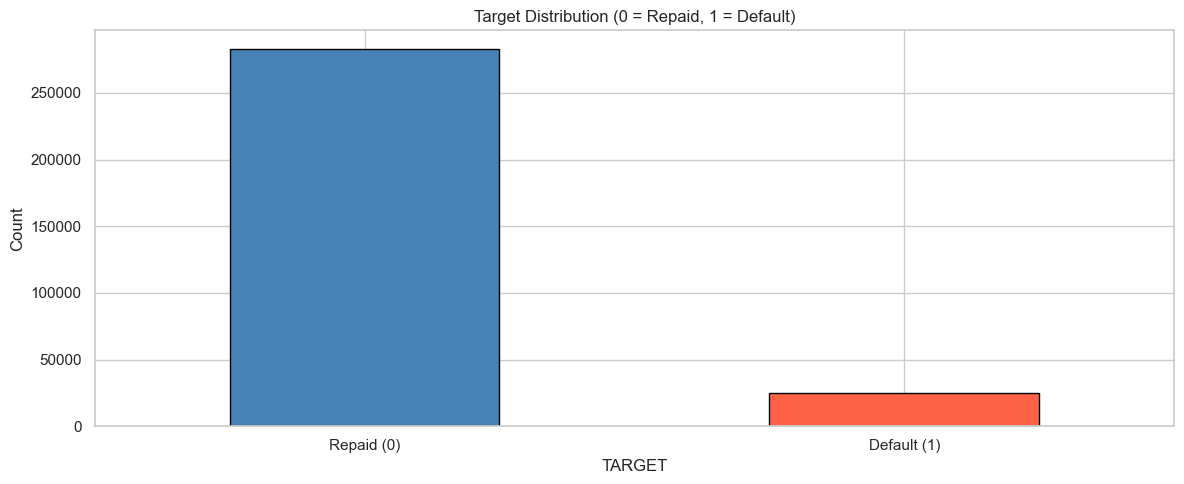

In [96]:
counts = app_train['TARGET'].value_counts()
print(counts)
print(f'Default rate: {counts[1] / len(app_train):.2%}')

counts.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Target Distribution (0 = Repaid, 1 = Default)')
plt.xticks([0, 1], ['Repaid (0)', 'Default (1)'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 1.2 Missing Values

In [97]:
print('--- application_train: top 15 columns with missing values ---')
missing = app_train.isnull().mean().sort_values(ascending=False)
print(missing[missing > 0].head(15))

for name, df in [('previous_application', prev_app),
                 ('installments_payments', installments),
                 ('credit_card_balance',   credit_card)]:
    miss = df.isnull().mean()
    print(f'\n{name} - columns with >20% missing:')
    print(miss[miss > 0.2].sort_values(ascending=False))

--- application_train: top 15 columns with missing values ---
COMMONAREA_MEDI            0.6987
COMMONAREA_AVG             0.6987
COMMONAREA_MODE            0.6987
NONLIVINGAPARTMENTS_MODE   0.6943
NONLIVINGAPARTMENTS_AVG    0.6943
NONLIVINGAPARTMENTS_MEDI   0.6943
FONDKAPREMONT_MODE         0.6839
LIVINGAPARTMENTS_MODE      0.6835
LIVINGAPARTMENTS_AVG       0.6835
LIVINGAPARTMENTS_MEDI      0.6835
FLOORSMIN_AVG              0.6785
FLOORSMIN_MODE             0.6785
FLOORSMIN_MEDI             0.6785
YEARS_BUILD_MEDI           0.6650
YEARS_BUILD_MODE           0.6650
dtype: float64

previous_application - columns with >20% missing:
RATE_INTEREST_PRIMARY       0.9964
RATE_INTEREST_PRIVILEGED    0.9964
AMT_DOWN_PAYMENT            0.5364
RATE_DOWN_PAYMENT           0.5364
NAME_TYPE_SUITE             0.4912
DAYS_FIRST_DRAWING          0.4030
DAYS_FIRST_DUE              0.4030
DAYS_LAST_DUE_1ST_VERSION   0.4030
DAYS_LAST_DUE               0.4030
DAYS_TERMINATION            0.4030
NFLAG_INSURE

## 2. Feature Engineering

Key decisions based on prior SHAP results:
- EXT_SOURCE features dominated importance, so we add interaction terms between them
- Installment and credit card features were underrepresented - we add more targeted signals
- All aggregations are at `SK_ID_CURR` level for merging

### 2.1 Application-Level Features

In [98]:
def engineer_app_features(df):
    df = df.copy()

    # Financial ratios
    df['credit_income_ratio']  = df['AMT_CREDIT']      / (df['AMT_INCOME_TOTAL'] + 1)
    df['annuity_income_ratio'] = df['AMT_ANNUITY']     / (df['AMT_INCOME_TOTAL'] + 1)
    df['goods_credit_ratio']   = df['AMT_GOODS_PRICE'] / (df['AMT_CREDIT'] + 1)
    df['credit_term']          = df['AMT_ANNUITY']     / (df['AMT_CREDIT'] + 1)
    df['income_per_person']    = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'].fillna(1) + 1)

    # Age and employment
    df['age_years']       = df['DAYS_BIRTH'] / -365
    df['employed_years']  = df['DAYS_EMPLOYED'].apply(lambda x: x / -365 if x < 0 else np.nan)
    df['employed_to_age'] = df['employed_years'] / (df['age_years'] + 1)

    # EXT_SOURCE composites - these dominated SHAP, so add interaction terms
    ext = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']]
    df['ext_source_mean']  = ext.mean(axis=1)
    df['ext_source_min']   = ext.min(axis=1)
    df['ext_source_max']   = ext.max(axis=1)
    df['ext_source_std']   = ext.std(axis=1)
    # Pairwise products capture joint credit score effects
    df['ext_12'] = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2']
    df['ext_13'] = df['EXT_SOURCE_1'] * df['EXT_SOURCE_3']
    df['ext_23'] = df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']
    # How far below average is the weakest score
    df['ext_source_range'] = df['ext_source_max'] - df['ext_source_min']

    # Missing-value indicators (missingness is itself informative)
    for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
        df[f'{col}_MISSING'] = df[col].isnull().astype(int)

    return df

app_train = engineer_app_features(app_train)
app_test  = engineer_app_features(app_test)
print('Application features added. New shape:', app_train.shape)

Application features added. New shape: (307511, 141)


### 2.2 Previous Application Features

In [99]:
prev_agg = prev_app.groupby('SK_ID_CURR').agg(
    prev_app_count          = ('SK_ID_PREV',           'count'),
    prev_approved_count     = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    prev_refused_count      = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    prev_amt_credit_mean    = ('AMT_CREDIT',           'mean'),
    prev_amt_annuity_mean   = ('AMT_ANNUITY',          'mean'),
    prev_amt_appl_mean      = ('AMT_APPLICATION',      'mean'),
    prev_days_decision_mean = ('DAYS_DECISION',        'mean'),
).reset_index()

prev_agg['prev_approval_rate'] = prev_agg['prev_approved_count'] / (prev_agg['prev_app_count'] + 1)
prev_agg['prev_refusal_rate']  = prev_agg['prev_refused_count']  / (prev_agg['prev_app_count'] + 1)
# Credit amount requested vs approved ratio - large gap signals risk
prev_agg['prev_credit_appl_ratio'] = prev_agg['prev_amt_credit_mean'] / (prev_agg['prev_amt_appl_mean'] + 1)

prev_mode = (
    prev_app.groupby('SK_ID_CURR')['NAME_CONTRACT_STATUS']
    .agg(lambda x: x.mode()[0] if len(x) > 0 else np.nan)
    .reset_index()
    .rename(columns={'NAME_CONTRACT_STATUS': 'prev_contract_status_mode'})
)
prev_agg = prev_agg.merge(prev_mode, on='SK_ID_CURR', how='left')
print('Previous application features:', prev_agg.shape)

Previous application features: (338857, 12)


### 2.3 Installments Payment Features

In [100]:
installments['payment_delay'] = installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']
installments['payment_diff']  = installments['AMT_PAYMENT'] - installments['AMT_INSTALMENT']
installments['is_late']       = (installments['payment_delay'] > 0).astype(int)
installments['is_underpaid']  = (installments['payment_diff']  < 0).astype(int)
installments['payment_ratio'] = installments['AMT_PAYMENT'] / (installments['AMT_INSTALMENT'] + 1)

inst_agg = installments.groupby('SK_ID_CURR').agg(
    inst_count              = ('SK_ID_PREV',     'count'),
    inst_delay_mean         = ('payment_delay',  'mean'),
    inst_delay_max          = ('payment_delay',  'max'),
    inst_delay_std          = ('payment_delay',  'std'),
    inst_late_count         = ('is_late',        'sum'),
    inst_underpaid_count    = ('is_underpaid',   'sum'),
    inst_payment_diff_mean  = ('payment_diff',   'mean'),
    inst_payment_diff_min   = ('payment_diff',   'min'),
    inst_payment_ratio_mean = ('payment_ratio',  'mean'),
    inst_payment_ratio_min  = ('payment_ratio',  'min'),
).reset_index()

inst_agg['inst_late_rate']      = inst_agg['inst_late_count']      / (inst_agg['inst_count'] + 1)
inst_agg['inst_underpaid_rate'] = inst_agg['inst_underpaid_count'] / (inst_agg['inst_count'] + 1)
print('Installment features:', inst_agg.shape)

Installment features: (339587, 13)


### 2.4 Credit Card Balance Features

In [101]:
credit_card['utilization']    = credit_card['AMT_BALANCE'] / (credit_card['AMT_CREDIT_LIMIT_ACTUAL'] + 1)
credit_card['drawings_ratio'] = credit_card['AMT_DRAWINGS_CURRENT'] / (credit_card['AMT_CREDIT_LIMIT_ACTUAL'] + 1)

cc_agg = credit_card.groupby('SK_ID_CURR').agg(
    cc_months_count        = ('MONTHS_BALANCE',          'count'),
    cc_balance_mean        = ('AMT_BALANCE',             'mean'),
    cc_balance_max         = ('AMT_BALANCE',             'max'),
    cc_credit_limit_mean   = ('AMT_CREDIT_LIMIT_ACTUAL', 'mean'),
    cc_utilization_mean    = ('utilization',             'mean'),
    cc_utilization_max     = ('utilization',             'max'),
    cc_utilization_std     = ('utilization',             'std'),
    cc_drawings_ratio_mean = ('drawings_ratio',          'mean'),
    cc_dpd_mean            = ('SK_DPD',                  'mean'),
    cc_dpd_max             = ('SK_DPD',                  'max'),
    cc_payment_mean        = ('AMT_PAYMENT_CURRENT',     'mean'),
).reset_index()
print('Credit card features:', cc_agg.shape)

Credit card features: (103558, 12)


### 2.5 Merge All Features

In [102]:
def merge_features(df):
    df = df.merge(prev_agg, on='SK_ID_CURR', how='left')
    df = df.merge(inst_agg, on='SK_ID_CURR', how='left')
    df = df.merge(cc_agg,   on='SK_ID_CURR', how='left')
    return df

train_full = merge_features(app_train)
test_full  = merge_features(app_test)
print('Merged train shape:', train_full.shape)
print('Merged test shape: ', test_full.shape)

Merged train shape: (307511, 175)
Merged test shape:  (48744, 174)


## 3. Preprocessing

- Median imputation for numeric, most-frequent + OHE for categorical
- Stratified 80/20 split
- Boosting models use a named numeric DataFrame (no scaling needed, handles NaN natively)
- LR and RF use the full scaled+OHE array

In [103]:
y = train_full['TARGET']
X = train_full.drop(columns=['TARGET', 'SK_ID_CURR'])
X_test_final = test_full.drop(columns=['SK_ID_CURR'])

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()
print(f'Numeric features:     {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}')

Numeric features:     156
Categorical features: 17


In [104]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Full processed arrays for LR and RF
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test_final)

# Named numeric DataFrames for boosting + SHAP (readable feature names)
num_imputer  = SimpleImputer(strategy='median')
X_train_df   = pd.DataFrame(num_imputer.fit_transform(X_train[num_cols]), columns=num_cols)
X_val_df     = pd.DataFrame(num_imputer.transform(X_val[num_cols]),       columns=num_cols)
X_test_df    = pd.DataFrame(num_imputer.transform(X_test_final[num_cols]),columns=num_cols)

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'Train: {X_train_proc.shape}, Val: {X_val_proc.shape}')
print(f'Class ratio (neg/pos): {scale_pos_weight:.2f}')

Train: (246008, 300), Val: (61503, 300)
Class ratio (neg/pos): 11.39


## 4. Evaluation Helper

Regular accuracy is misleading on this imbalanced dataset (~8% default rate). We track ROC-AUC, F1, Precision, Recall, and Balanced Accuracy.

In [105]:
results = {}

def evaluate(name, model, X_tr, y_tr, X_v, y_v, threshold=0.5):
    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_v)[:, 1]
    preds = (proba >= threshold).astype(int)
    metrics = {
        'ROC_AUC':           round(roc_auc_score(y_v, proba), 4),
        'F1':                round(f1_score(y_v, preds, zero_division=0), 4),
        'Precision':         round(precision_score(y_v, preds, zero_division=0), 4),
        'Recall':            round(recall_score(y_v, preds, zero_division=0), 4),
        'Balanced_Accuracy': round(balanced_accuracy_score(y_v, preds), 4),
    }
    results[name] = metrics
    print(f'{name}')
    for k, v in metrics.items():
        print(f'  {k}: {v}')
    print()
    return model, proba

def show_confusion(name, model, X_v, y_v):
    preds = model.predict(X_v)
    ConfusionMatrixDisplay(
        confusion_matrix(y_v, preds),
        display_labels=['Repaid', 'Default']
    ).plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.tight_layout()
    plt.show()

## 5. Baseline Models

### 5.1 Logistic Regression

In [106]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
lr, lr_proba = evaluate('Logistic Regression', lr, X_train_proc, y_train, X_val_proc, y_val)

Logistic Regression
  ROC_AUC: 0.7648
  F1: 0.2726
  Precision: 0.1696
  Recall: 0.6939
  Balanced_Accuracy: 0.6977



### 5.2 Random Forest

`balanced_subsample` resamples each tree's bootstrap to be balanced. `max_depth=15` and `min_samples_leaf=50` prevent the majority class from dominating.

In [107]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_features='sqrt',
    max_depth=15,
    min_samples_leaf=50,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=SEED
)
rf, rf_proba = evaluate('Random Forest', rf, X_train_proc, y_train, X_val_proc, y_val)

Random Forest
  ROC_AUC: 0.7621
  F1: 0.2972
  Precision: 0.1986
  Recall: 0.5903
  Balanced_Accuracy: 0.6906



### 5.3 Confusion Matrices for Baselines

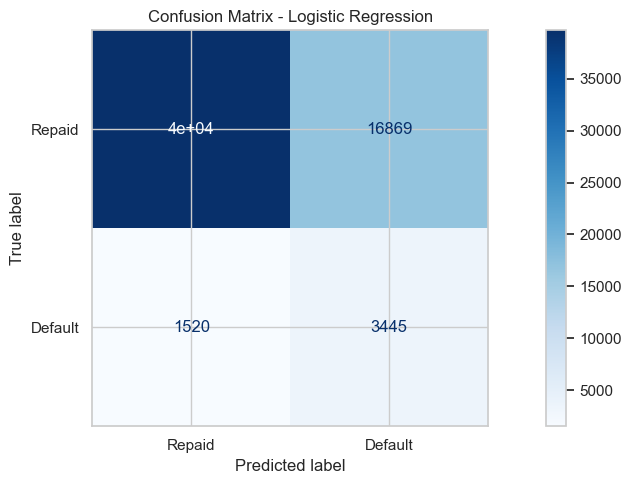

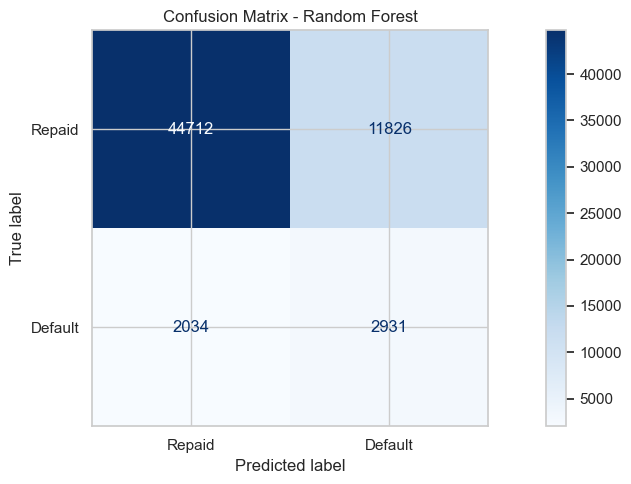

In [108]:
show_confusion('Logistic Regression', lr, X_val_proc, y_val)
show_confusion('Random Forest',       rf, X_val_proc, y_val)

## 6. Boosting Models

### Tuning Iteration History

**Iteration 1 - Broad RandomizedSearchCV (n_iter=20, 3-fold CV):**
- XGBoost best params: `n_estimators=500, max_depth=4, lr=0.05, subsample=0.8, colsample=0.8, min_child_weight=5, reg_lambda=5, reg_alpha=0`
- XGBoost result: ROC-AUC 0.7758, F1 0.2861, Balanced Accuracy 0.7064
- LightGBM best params: `n_estimators=300, num_leaves=31, max_depth=10, lr=0.05, subsample=0.9, colsample=0.7, min_child_samples=100, reg_lambda=0.1, reg_alpha=0`
- LightGBM result: ROC-AUC 0.7759, F1 0.2887, Balanced Accuracy 0.7075
- Issue: broad search took 20+ minutes; tuning barely improved over defaults

**Iteration 2 - Focused search around Iteration 1 best params (n_iter=15, 2-fold CV) + early stopping:**
- Search space narrowed to a tight neighborhood around the known-good params
- Added `early_stopping_rounds=50` on final refit so trees stop when validation AUC plateaus
- Added EXT_SOURCE pairwise interaction features (`ext_12`, `ext_13`, `ext_23`) since those features dominated SHAP in Iteration 1
- Added `gamma` (min split gain) to XGBoost search to improve handling of imbalanced classes
- Removed VotingClassifier (redundant with probability averaging, added complexity)
- Estimated runtime: ~5-8 minutes vs 20+ minutes in Iteration 1

### 6.1 XGBoost - Default

In [109]:
xgb_default = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=SEED,
    n_jobs=-1,
    tree_method='hist'
)
xgb_default, xgb_default_proba = evaluate(
    'XGBoost (default)', xgb_default, X_train_df, y_train, X_val_df, y_val
)

XGBoost (default)
  ROC_AUC: 0.7607
  F1: 0.2874
  Precision: 0.1874
  Recall: 0.6163
  Balanced_Accuracy: 0.6908



### 6.2 LightGBM - Default

In [110]:
lgb_default = LGBMClassifier(
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)
lgb_default, lgb_default_proba = evaluate(
    'LightGBM (default)', lgb_default, X_train_df, y_train, X_val_df, y_val
)

LightGBM (default)
  ROC_AUC: 0.7734
  F1: 0.2834
  Precision: 0.1785
  Recall: 0.6878
  Balanced_Accuracy: 0.7049



### 6.3 CatBoost - Default (if available)

In [111]:
if CATBOOST_AVAILABLE:
    cb_default = CatBoostClassifier(
        auto_class_weights='Balanced', eval_metric='AUC',
        random_seed=SEED, verbose=0
    )
    cb_default, cb_default_proba = evaluate(
        'CatBoost (default)', cb_default, X_train_df, y_train, X_val_df, y_val
    )
else:
    print('CatBoost not available, skipping.')

CatBoost (default)
  ROC_AUC: 0.7699
  F1: 0.2995
  Precision: 0.1982
  Recall: 0.6125
  Balanced_Accuracy: 0.6975



### 6.4 XGBoost - Focused Tuning with Early Stopping

Search is centered on the best params from the previous run. `early_stopping_rounds=50` means training stops if validation AUC hasn't improved in 50 rounds - no need to guess the right `n_estimators`.

In [112]:
# Focused search around known-good params from prior run
# Prior best: n_estimators=500, max_depth=4, lr=0.05, subsample=0.8, colsample=0.8
xgb_param_grid = {
    'n_estimators':     [500, 700, 1000],       # higher ceiling, early stopping handles it
    'max_depth':        [3, 4, 5],              # shallow trees work well here
    'learning_rate':    [0.03, 0.05, 0.08],     # around the known-good 0.05
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8],
    'min_child_weight': [3, 5, 10],             # higher = more conservative
    'reg_alpha':        [0, 0.05, 0.1],
    'reg_lambda':       [3, 5, 8],
    'gamma':            [0, 0.1, 0.2],          # min split gain
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos_weight, eval_metric='auc',
        random_state=SEED, n_jobs=-1, tree_method='hist'
    ),
    xgb_param_grid, n_iter=15, scoring='roc_auc',
    cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=SEED),
    random_state=SEED, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train_df, y_train)
print('Best XGBoost params:', xgb_search.best_params_)
print('Best CV ROC-AUC:    ', round(xgb_search.best_score_, 4))

Best XGBoost params: {'subsample': 0.8, 'reg_lambda': 8, 'reg_alpha': 0, 'n_estimators': 1000, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.7}
Best CV ROC-AUC:     0.7696


In [113]:
# Refit best config with early stopping on the validation set
best_xgb_params = xgb_search.best_params_.copy()
n_est = best_xgb_params.pop('n_estimators')

xgb_tuned = XGBClassifier(
    **best_xgb_params,
    n_estimators=n_est,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=SEED,
    n_jobs=-1,
    tree_method='hist',
    early_stopping_rounds=50
)
xgb_tuned.fit(
    X_train_df, y_train,
    eval_set=[(X_val_df, y_val)],
    verbose=False
)
print(f'Best iteration: {xgb_tuned.best_iteration}')

xgb_tuned_proba = xgb_tuned.predict_proba(X_val_df)[:, 1]
xgb_tuned_preds = (xgb_tuned_proba >= 0.5).astype(int)
results['XGBoost (tuned)'] = {
    'ROC_AUC':           round(roc_auc_score(y_val, xgb_tuned_proba), 4),
    'F1':                round(f1_score(y_val, xgb_tuned_preds, zero_division=0), 4),
    'Precision':         round(precision_score(y_val, xgb_tuned_preds, zero_division=0), 4),
    'Recall':            round(recall_score(y_val, xgb_tuned_preds, zero_division=0), 4),
    'Balanced_Accuracy': round(balanced_accuracy_score(y_val, xgb_tuned_preds), 4),
}
print('XGBoost (tuned):')
for k, v in results['XGBoost (tuned)'].items(): print(f'  {k}: {v}')

Best iteration: 998
XGBoost (tuned):
  ROC_AUC: 0.7774
  F1: 0.2894
  Precision: 0.1833
  Recall: 0.6874
  Balanced_Accuracy: 0.7092


### 6.5 LightGBM - Focused Tuning with Early Stopping

Prior best: `n_estimators=300, num_leaves=31, max_depth=10, lr=0.05, subsample=0.9`. We search a tight neighborhood. `callbacks=[early_stopping(50)]` stops training when validation AUC plateaus - much faster than fixed n_estimators.

In [114]:
from lightgbm import early_stopping as lgb_early_stopping, log_evaluation

# Focused search around known-good params
# Prior best: num_leaves=31, max_depth=10, lr=0.05, subsample=0.9, colsample=0.7
lgb_param_grid = {
    'n_estimators':      [500, 700, 1000],      # early stopping handles the ceiling
    'num_leaves':        [31, 47, 63],           # 31 was best, try slightly larger
    'max_depth':         [7, 10, 12],
    'learning_rate':     [0.03, 0.05, 0.08],
    'subsample':         [0.8, 0.9],
    'colsample_bytree':  [0.6, 0.7, 0.8],
    'min_child_samples': [50, 100, 150],        # higher = less overfitting
    'reg_alpha':         [0, 0.05, 0.1],
    'reg_lambda':        [0.05, 0.1, 0.3],
}

lgb_search = RandomizedSearchCV(
    LGBMClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1),
    lgb_param_grid, n_iter=15, scoring='roc_auc',
    cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=SEED),
    random_state=SEED, n_jobs=-1, verbose=0
)
lgb_search.fit(X_train_df, y_train)
print('Best LightGBM params:', lgb_search.best_params_)
print('Best CV ROC-AUC:     ', round(lgb_search.best_score_, 4))

Best LightGBM params: {'subsample': 0.9, 'reg_lambda': 0.05, 'reg_alpha': 0.05, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 150, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Best CV ROC-AUC:      0.7681


In [115]:
# Refit with early stopping on the validation set
best_lgb_params = lgb_search.best_params_.copy()
n_est_lgb = best_lgb_params.pop('n_estimators')

lgb_tuned = LGBMClassifier(
    **best_lgb_params,
    n_estimators=n_est_lgb,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)
lgb_tuned.fit(
    X_train_df, y_train,
    eval_set=[(X_val_df, y_val)],
    callbacks=[lgb_early_stopping(50, verbose=False), log_evaluation(-1)]
)
print(f'Best iteration: {lgb_tuned.best_iteration_}')

lgb_tuned_proba = lgb_tuned.predict_proba(X_val_df)[:, 1]
lgb_tuned_preds = (lgb_tuned_proba >= 0.5).astype(int)
results['LightGBM (tuned)'] = {
    'ROC_AUC':           round(roc_auc_score(y_val, lgb_tuned_proba), 4),
    'F1':                round(f1_score(y_val, lgb_tuned_preds, zero_division=0), 4),
    'Precision':         round(precision_score(y_val, lgb_tuned_preds, zero_division=0), 4),
    'Recall':            round(recall_score(y_val, lgb_tuned_preds, zero_division=0), 4),
    'Balanced_Accuracy': round(balanced_accuracy_score(y_val, lgb_tuned_preds), 4),
}
print('LightGBM (tuned):')
for k, v in results['LightGBM (tuned)'].items(): print(f'  {k}: {v}')

Best iteration: 500
LightGBM (tuned):
  ROC_AUC: 0.7763
  F1: 0.2876
  Precision: 0.1825
  Recall: 0.6777
  Balanced_Accuracy: 0.7056


## 7. Ensemble Model

Two ensemble approaches:
1. **Equal-weight average** - simple average of predicted probabilities
2. **ROC-AUC weighted average** - weight each model by its validation ROC-AUC so the better model contributes more

In [116]:
# Equal-weight average
ensemble_proba = (xgb_tuned_proba + lgb_tuned_proba) / 2
ensemble_preds = (ensemble_proba >= 0.5).astype(int)
results['Ensemble (avg)'] = {
    'ROC_AUC':           round(roc_auc_score(y_val, ensemble_proba), 4),
    'F1':                round(f1_score(y_val, ensemble_preds, zero_division=0), 4),
    'Precision':         round(precision_score(y_val, ensemble_preds, zero_division=0), 4),
    'Recall':            round(recall_score(y_val, ensemble_preds, zero_division=0), 4),
    'Balanced_Accuracy': round(balanced_accuracy_score(y_val, ensemble_preds), 4),
}
print('Ensemble (avg):')
for k, v in results['Ensemble (avg)'].items(): print(f'  {k}: {v}')

Ensemble (avg):
  ROC_AUC: 0.7776
  F1: 0.2894
  Precision: 0.1835
  Recall: 0.6842
  Balanced_Accuracy: 0.7085


In [117]:
# ROC-AUC weighted average
w_xgb = results['XGBoost (tuned)']['ROC_AUC']
w_lgb = results['LightGBM (tuned)']['ROC_AUC']
weighted_proba = (w_xgb * xgb_tuned_proba + w_lgb * lgb_tuned_proba) / (w_xgb + w_lgb)
weighted_preds = (weighted_proba >= 0.5).astype(int)
results['Ensemble (weighted)'] = {
    'ROC_AUC':           round(roc_auc_score(y_val, weighted_proba), 4),
    'F1':                round(f1_score(y_val, weighted_preds, zero_division=0), 4),
    'Precision':         round(precision_score(y_val, weighted_preds, zero_division=0), 4),
    'Recall':            round(recall_score(y_val, weighted_preds, zero_division=0), 4),
    'Balanced_Accuracy': round(balanced_accuracy_score(y_val, weighted_preds), 4),
}
print(f'Weights - XGBoost: {w_xgb:.4f}, LightGBM: {w_lgb:.4f}')
print('Ensemble (weighted):')
for k, v in results['Ensemble (weighted)'].items(): print(f'  {k}: {v}')

Weights - XGBoost: 0.7774, LightGBM: 0.7763
Ensemble (weighted):
  ROC_AUC: 0.7776
  F1: 0.2894
  Precision: 0.1835
  Recall: 0.684
  Balanced_Accuracy: 0.7084


## 8. Model Comparison

In [118]:
results_df = pd.DataFrame(results).T.astype(float)
results_df = results_df.sort_values('ROC_AUC', ascending=False)
print(results_df.to_string())

                     ROC_AUC     F1  Precision  Recall  Balanced_Accuracy
Ensemble (avg)        0.7776 0.2894     0.1835  0.6842             0.7085
Ensemble (weighted)   0.7776 0.2894     0.1835  0.6840             0.7084
XGBoost (tuned)       0.7774 0.2894     0.1833  0.6874             0.7092
LightGBM (tuned)      0.7763 0.2876     0.1825  0.6777             0.7056
LightGBM (default)    0.7734 0.2834     0.1785  0.6878             0.7049
CatBoost (default)    0.7699 0.2995     0.1982  0.6125             0.6975
Logistic Regression   0.7648 0.2726     0.1696  0.6939             0.6977
Random Forest         0.7621 0.2972     0.1986  0.5903             0.6906
XGBoost (default)     0.7607 0.2874     0.1874  0.6163             0.6908


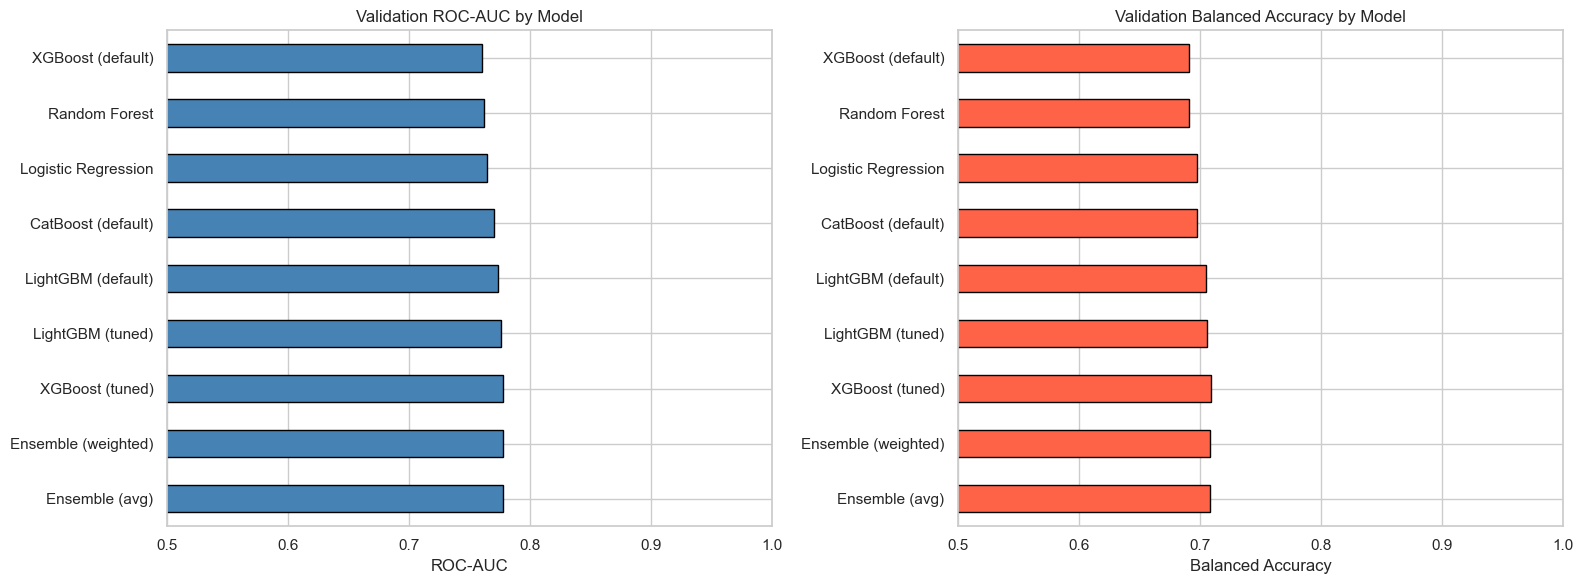

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
results_df['ROC_AUC'].plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Validation ROC-AUC by Model')
axes[0].set_xlabel('ROC-AUC')
axes[0].set_xlim(0.5, 1.0)
results_df['Balanced_Accuracy'].plot(kind='barh', ax=axes[1], color='tomato', edgecolor='black')
axes[1].set_title('Validation Balanced Accuracy by Model')
axes[1].set_xlabel('Balanced Accuracy')
axes[1].set_xlim(0.5, 1.0)
plt.tight_layout()
plt.show()

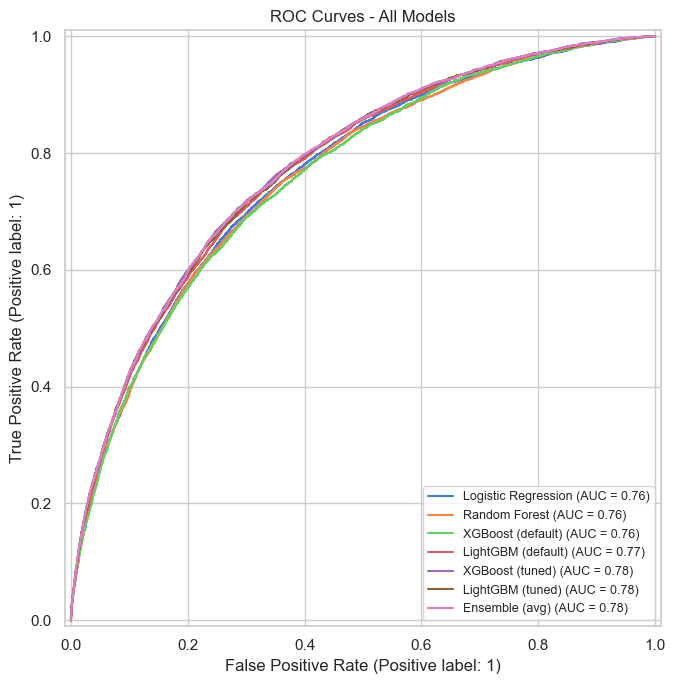

In [120]:
fig, ax = plt.subplots(figsize=(10, 7))
model_probas = {
    'Logistic Regression':        lr_proba,
    'Random Forest':               rf_proba,
    'XGBoost (default)':           xgb_default_proba,
    'LightGBM (default)':          lgb_default_proba,
    'XGBoost (tuned)':             xgb_tuned_proba,
    'LightGBM (tuned)':            lgb_tuned_proba,
    'Ensemble (avg)':              ensemble_proba,
}
for name, proba in model_probas.items():
    RocCurveDisplay.from_predictions(y_val, proba, name=name, ax=ax)
ax.set_title('ROC Curves - All Models')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

Best model: Ensemble (avg)


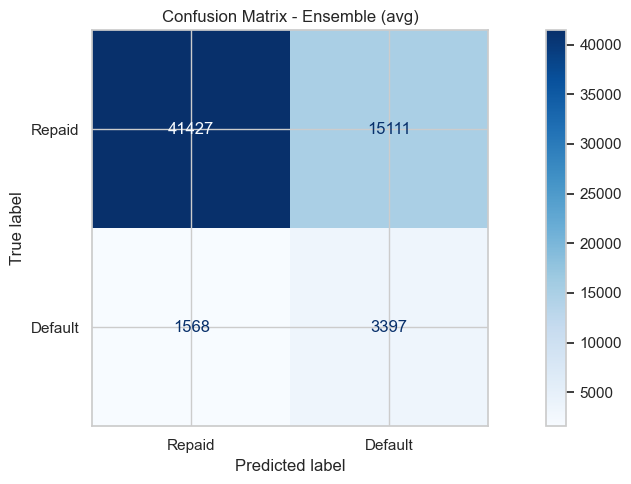

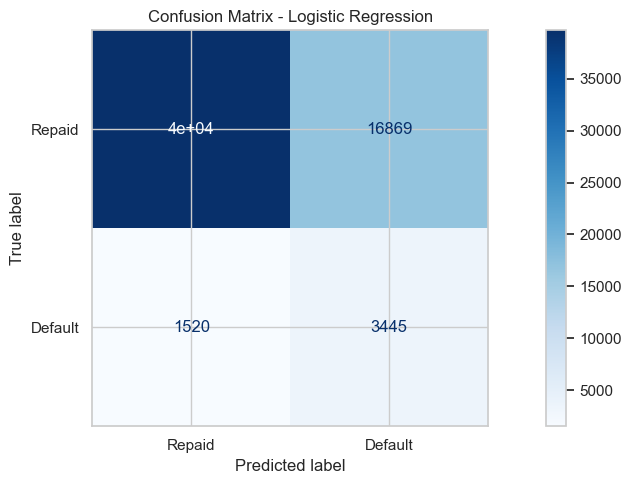

In [121]:
best_name = results_df.index[0]
print(f'Best model: {best_name}')

best_proba_map = {
    'Ensemble (avg)':      ensemble_proba,
    'Ensemble (weighted)': weighted_proba,
    'XGBoost (tuned)':     xgb_tuned_proba,
    'LightGBM (tuned)':    lgb_tuned_proba,
}
best_proba = best_proba_map.get(best_name, ensemble_proba)
best_preds = (best_proba >= 0.5).astype(int)

ConfusionMatrixDisplay(
    confusion_matrix(y_val, best_preds), display_labels=['Repaid', 'Default']
).plot(cmap='Blues')
plt.title(f'Confusion Matrix - {best_name}')
plt.tight_layout()
plt.show()

show_confusion('Logistic Regression', lr, X_val_proc, y_val)

## 9. SHAP Analysis and Feature Trustworthiness

We use the named numeric DataFrame so feature names are readable. Checks:
- Which features actually drive the model
- Whether they make intuitive sense for borrower risk
- Whether the same features stay important across LightGBM, XGBoost, and Random Forest

### 9.1 SHAP for LightGBM (Tuned)

In [122]:
shap_idx    = X_val_df.sample(min(2000, len(X_val_df)), random_state=SEED).index
shap_sample = X_val_df.loc[shap_idx]

explainer_lgb   = shap.TreeExplainer(lgb_tuned)
shap_values_lgb = explainer_lgb.shap_values(shap_sample)
sv_lgb = shap_values_lgb[1] if isinstance(shap_values_lgb, list) else shap_values_lgb
print('SHAP values computed. Shape:', sv_lgb.shape)

SHAP values computed. Shape: (2000, 156)


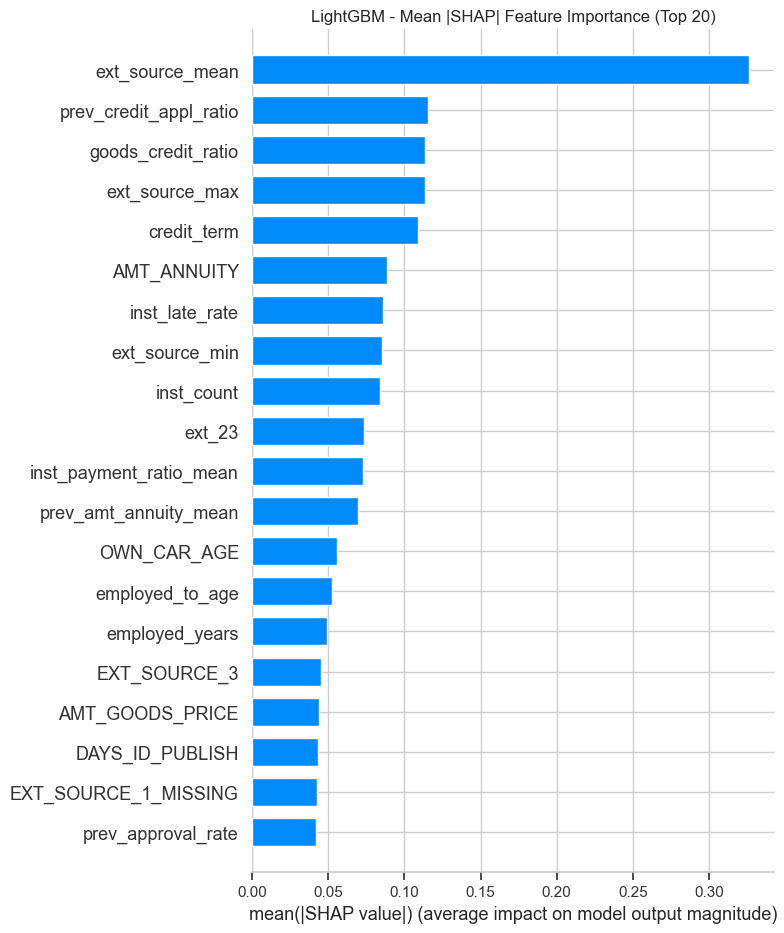

In [123]:
plt.figure(figsize=(12, 8))
shap.summary_plot(sv_lgb, shap_sample, plot_type='bar', max_display=20, show=False)
plt.title('LightGBM - Mean |SHAP| Feature Importance (Top 20)')
plt.tight_layout()
plt.show()

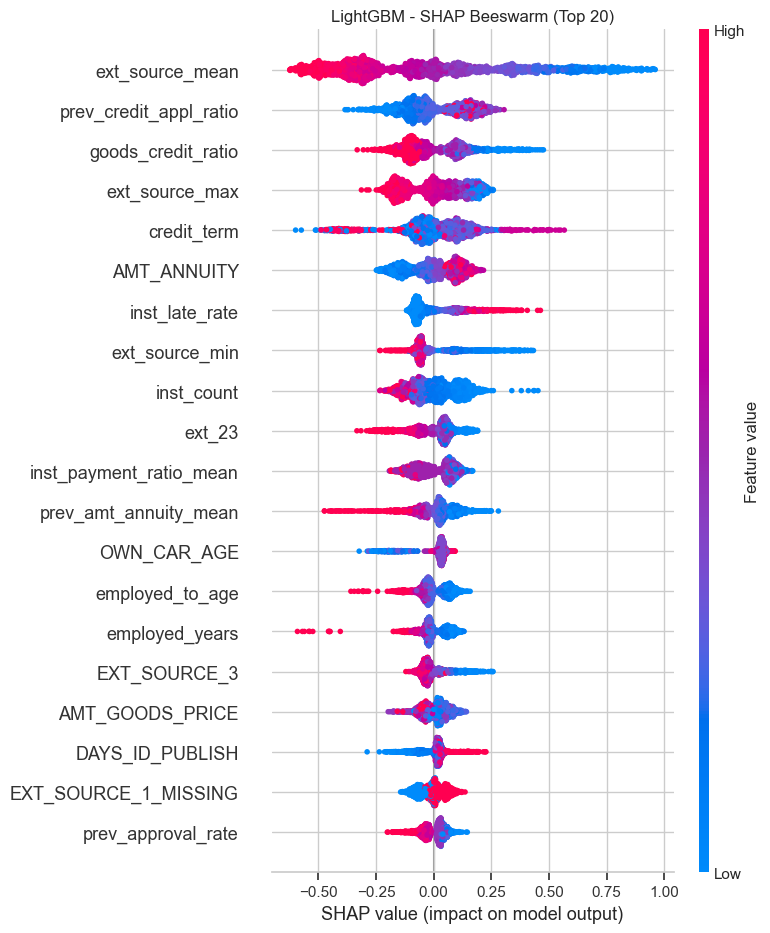

In [124]:
plt.figure(figsize=(12, 10))
shap.summary_plot(sv_lgb, shap_sample, max_display=20, show=False)
plt.title('LightGBM - SHAP Beeswarm (Top 20)')
plt.tight_layout()
plt.show()

### 9.2 SHAP for XGBoost (Tuned)

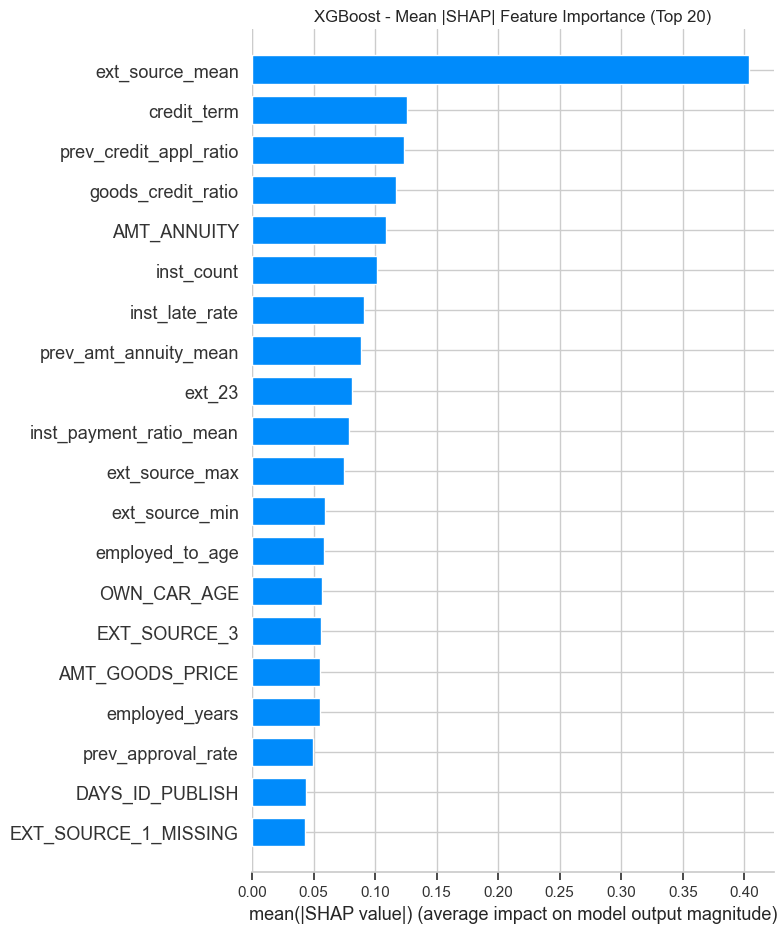

In [125]:
explainer_xgb   = shap.TreeExplainer(xgb_tuned)
shap_values_xgb = explainer_xgb.shap_values(shap_sample)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_xgb, shap_sample, plot_type='bar', max_display=20, show=False)
plt.title('XGBoost - Mean |SHAP| Feature Importance (Top 20)')
plt.tight_layout()
plt.show()

### 9.3 SHAP Dependence Plots for Top Features

Top 4 features by mean |SHAP|: ['ext_source_mean', 'prev_credit_appl_ratio', 'goods_credit_ratio', 'ext_source_max']


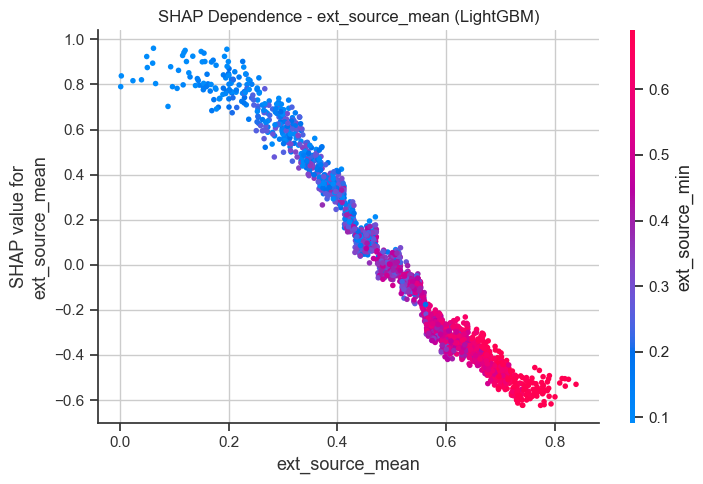

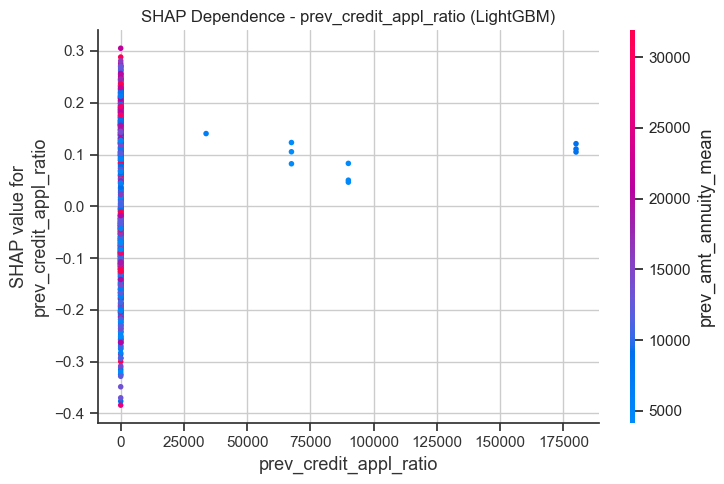

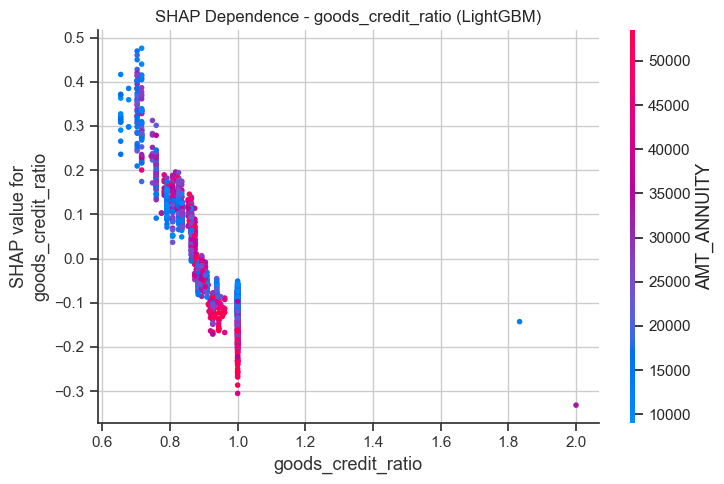

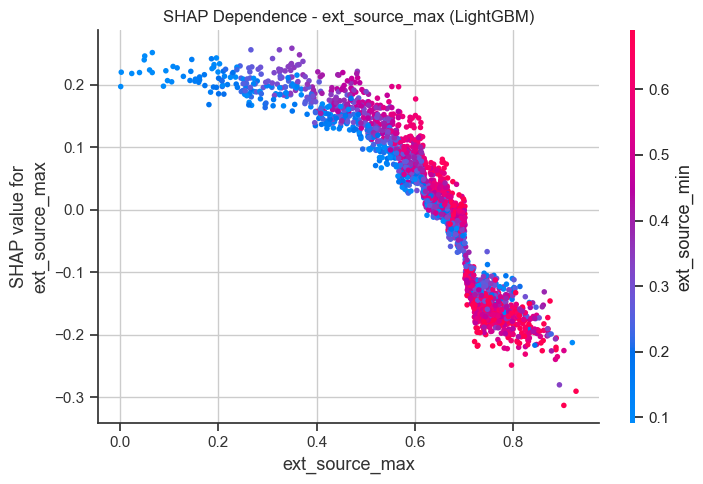

In [126]:
lgb_mean_shap = pd.Series(
    np.abs(sv_lgb).mean(axis=0), index=shap_sample.columns
).sort_values(ascending=False)

top_features = lgb_mean_shap.head(4).index.tolist()
print('Top 4 features by mean |SHAP|:', top_features)

for feat in top_features:
    shap.dependence_plot(feat, sv_lgb, shap_sample, show=False)
    plt.title(f'SHAP Dependence - {feat} (LightGBM)')
    plt.tight_layout()
    plt.show()

### 9.4 Cross-Model Feature Importance Comparison

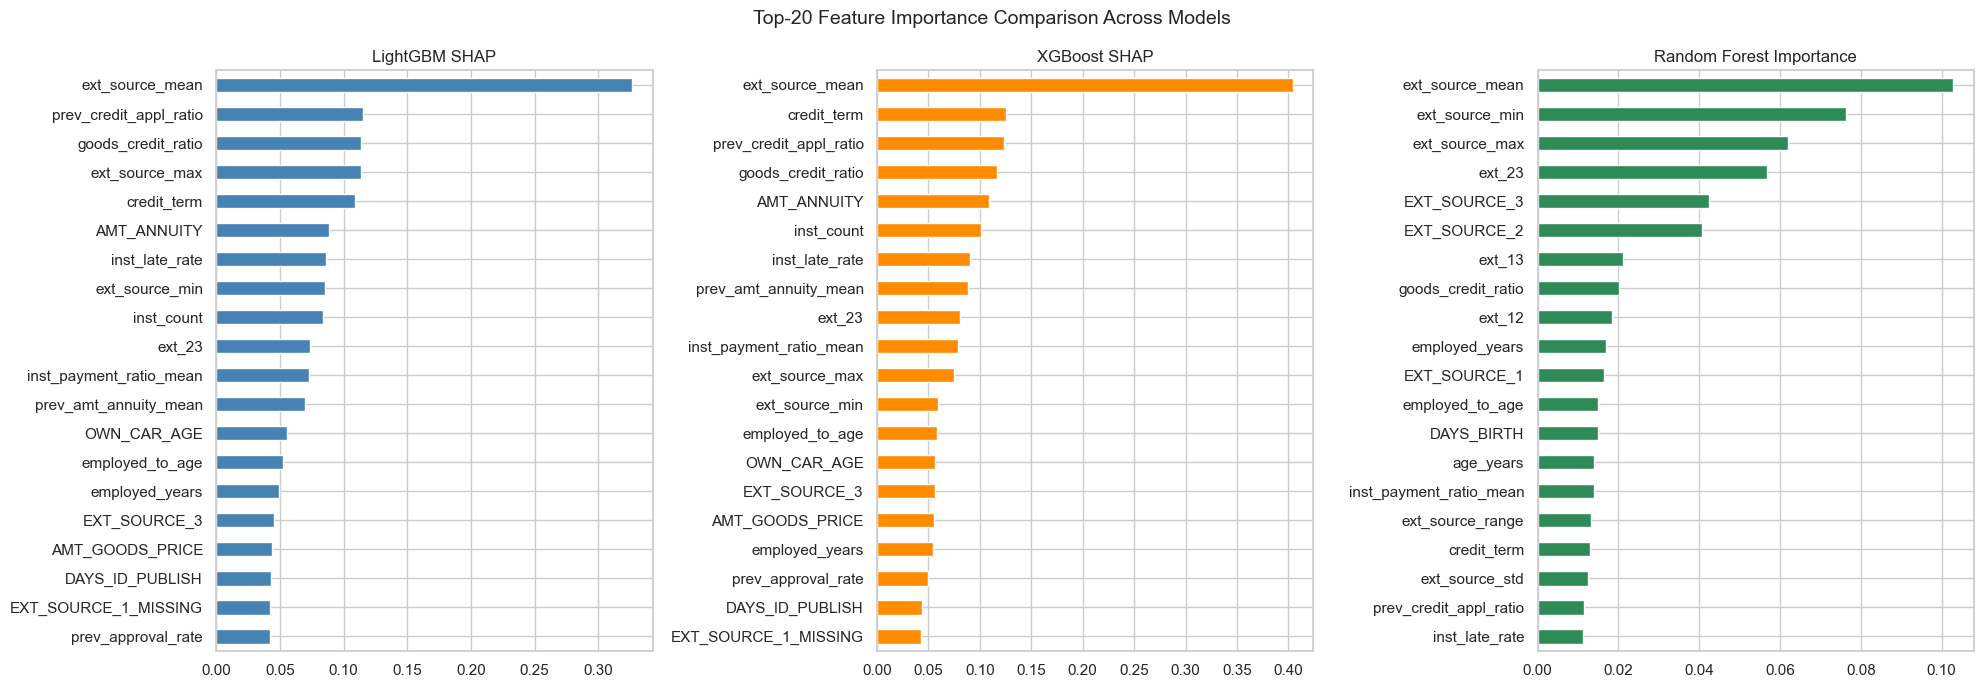

In [127]:
lgb_imp = pd.Series(np.abs(sv_lgb).mean(axis=0),          index=shap_sample.columns).nlargest(20).sort_values()
xgb_imp = pd.Series(np.abs(shap_values_xgb).mean(axis=0), index=shap_sample.columns).nlargest(20).sort_values()
rf_imp  = pd.Series(rf.feature_importances_[:len(num_cols)], index=num_cols).nlargest(20).sort_values()

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
lgb_imp.plot(kind='barh', ax=axes[0], color='steelblue',  title='LightGBM SHAP')
xgb_imp.plot(kind='barh', ax=axes[1], color='darkorange', title='XGBoost SHAP')
rf_imp.plot( kind='barh', ax=axes[2], color='seagreen',   title='Random Forest Importance')
plt.suptitle('Top-20 Feature Importance Comparison Across Models', fontsize=14)
plt.tight_layout()
plt.show()

In [128]:
lgb_top20 = set(lgb_mean_shap.head(20).index)
xgb_top20 = set(pd.Series(np.abs(shap_values_xgb).mean(axis=0), index=shap_sample.columns).nlargest(20).index)
rf_top20  = set(pd.Series(rf.feature_importances_[:len(num_cols)], index=num_cols).nlargest(20).index)

consistent = lgb_top20 & xgb_top20 & rf_top20
print(f'Features in top 20 across ALL three models ({len(consistent)}):')
for f in sorted(consistent): print(f'  {f}')

boost_only = (lgb_top20 & xgb_top20) - rf_top20
print(f'\nIn both boosting models but NOT Random Forest ({len(boost_only)}) - interpret with caution:')
for f in sorted(boost_only): print(f'  {f}')

Features in top 20 across ALL three models (12):
  EXT_SOURCE_3
  credit_term
  employed_to_age
  employed_years
  ext_23
  ext_source_max
  ext_source_mean
  ext_source_min
  goods_credit_ratio
  inst_late_rate
  inst_payment_ratio_mean
  prev_credit_appl_ratio

In both boosting models but NOT Random Forest (8) - interpret with caution:
  AMT_ANNUITY
  AMT_GOODS_PRICE
  DAYS_ID_PUBLISH
  EXT_SOURCE_1_MISSING
  OWN_CAR_AGE
  inst_count
  prev_amt_annuity_mean
  prev_approval_rate
